# Simple Actor-Critic (Defender) vs. DQN (Attacker) for the Budgeted Attack-Defense Game

In [25]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from collections import namedtuple, deque

In [26]:
# Necessary imports for the attack-defense problem
# Assuming 'utils.py' exists in the same directory
from utils import prob_success, attacker_lingo_model 

# Parameters
n_targets = 5 # Number of targets
alpha, beta, A = 1, 1, 0.1
attacker_budget = 5 # Attacker's investment (Million USD)
defender_budget = 30 # Defender's Investment (Million USD)

# Infrastructure valuations for n targets
B = np.array([50, 20, 35, 45, 30]) # Attacker's valuations 
D = np.array([50, 150, 100, 80, 120]) # Defender's valuations

# DQN Parameters
BATCH_SIZE = 64
GAMMA = 0.99 # Discount factor, from original AC update
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 5000
TARGET_UPDATE = 10 # How often to update the target network
BUFFER_CAPACITY = 10000

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
# Simple 2-layer neural network for Actor
class Actor(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_targets)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # Softmax to get allocation probabilities
        return F.softmax(x, dim=-1)

# Simple 2-layer neural network for Critic
class Critic(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        value = self.fc2(x)
        return value

In [28]:
# DQN Helper Classes and Functions

def get_all_allocations(n_targets, budget):
    """
    Generates all possible integer allocations of a budget across n_targets.
    """
    # This is equivalent to combinations with replacement
    # We use a recursive helper function
    
    allocs = []
    def find_allocs_recursive(remaining_budget, current_alloc, target_index):
        if target_index == n_targets - 1:
            # Last target gets whatever is left
            current_alloc.append(remaining_budget)
            allocs.append(tuple(current_alloc))
            current_alloc.pop()
            return

        for i in range(remaining_budget + 1):
            current_alloc.append(i)
            find_allocs_recursive(remaining_budget - i, current_alloc, target_index + 1)
            current_alloc.pop()

    find_allocs_recursive(budget, [], 0)
    
    # Convert tuples to tensors
    alloc_tensors = [torch.tensor(alloc, dtype=torch.float32) for alloc in allocs]
    return alloc_tensors

# Replay Memory
Transition = namedtuple('Transition',
                        ('state', 'action', 'reward', 'next_state'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# DQN Network
class QNetwork(nn.Module):
    def __init__(self, n_targets, n_actions, hidden_size=64):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_actions)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        return self.fc2(x)

In [29]:
# Agent class combining Actor and Critic (for Defender)
class ActorCriticAgent:
    def __init__(self, n_targets, budget, lr_actor=1e-3, lr_critic=1e-3):
        self.n_targets = n_targets
        self.budget = budget
        
        self.actor = Actor(n_targets)
        self.critic = Critic(n_targets)
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
    
    def get_allocation(self, state):
        """Get budget allocation across targets"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        probs = self.actor(state_tensor)
        
        # Sample from the distribution
        dist = torch.distributions.Categorical(probs)
        # Sample 'budget' number of times
        actions = dist.sample((self.budget,))
        
        # Convert to allocation vector
        allocation = torch.zeros(self.n_targets)
        for a in actions:
            allocation[a] += 1
        
        log_probs = dist.log_prob(actions).sum()
        
        return allocation, log_probs
    
    def update(self, state, log_prob, reward, next_state, gamma=0.99):
        """Update actor and critic networks"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
        
        # Critic update
        current_value = self.critic(state_tensor)
        next_value = self.critic(next_state_tensor)
        td_target = reward + gamma * next_value
        td_error = td_target - current_value
        
        critic_loss = td_error.pow(2).mean()
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # Actor update
        advantage = td_error.detach()
        actor_loss = -(log_prob * advantage)
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

In [30]:
# DQN Agent Class (for Attacker)

class DQNAgent:
    def __init__(self, n_targets, budget, lr=1e-3):
        self.n_targets = n_targets
        self.budget = budget
        self.gamma = GAMMA
        
        # Get all possible allocation actions
        self.allocations = get_all_allocations(n_targets, budget)
        self.n_actions = len(self.allocations)
        # Move allocations to device for easy lookup
        self.allocations_tensor = torch.stack(self.allocations).to(device)
        
        self.q_network = QNetwork(n_targets, self.n_actions).to(device)
        self.target_network = QNetwork(n_targets, self.n_actions).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval() # Target net is only for inference
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer(BUFFER_CAPACITY)
        self.steps_done = 0

    def get_allocation(self, state):
        """
        Get budget allocation using epsilon-greedy policy.
        Returns the allocation tensor and the index of the action.
        """
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
                        math.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1
        
        if random.random() > eps_threshold:
            # Exploit: get best action from Q-network
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.q_network(state_tensor)
                action_index = q_values.max(1)[1].item()
        else:
            # Explore: pick a random action
            action_index = random.randrange(self.n_actions)
            
        allocation = self.allocations_tensor[action_index]
        return allocation, action_index

    def push_to_memory(self, state, action_index, reward, next_state):
        """Pushes a transition to the replay buffer"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_tensor = torch.tensor([[action_index]], device=device, dtype=torch.long)
        reward_tensor = torch.tensor([reward], device=device, dtype=torch.float32)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
        
        self.memory.push(state_tensor, action_tensor, reward_tensor, next_state_tensor)

    def learn(self):
        """Update Q-network from a batch of transitions"""
        if len(self.memory) < BATCH_SIZE:
            return

        transitions = self.memory.sample(BATCH_SIZE)
        # Transpose the batch
        batch = Transition(*zip(*transitions))

        # Concatenate the batch elements
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        next_state_batch = torch.cat(batch.next_state)
        
        # Note: In this specific problem, the state doesn't change,
        # so state_batch and next_state_batch are the same.
        # But we follow the standard DQN update logic as the AC agent
        # also used a gamma and next_state.

        # Q(s, a) - The Q-value for the action taken
        state_action_values = self.q_network(state_batch).gather(1, action_batch)

        # V(s') = max_a' Q_target(s', a')
        # We use target_network for stability.
        next_state_values = self.target_network(next_state_batch).max(1)[0].detach()
        
        # Expected Q-value: R + gamma * V(s')
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch

        # Compute loss (Mean Squared Error)
        loss = F.mse_loss(state_action_values, expected_state_action_values.unsqueeze(1))
        
        # Optimize the model
        self.optimizer.zero_grad()
        loss.backward()
        # Clip gradients (optional but good practice)
        # for param in self.q_network.parameters():
        #     param.grad.data.clamp_(-1, 1)
        self.optimizer.step()

In [31]:
class AttackDefenseGame:
    def __init__(self, n_targets, attacker_budget, defender_budget):
        self.n_targets = n_targets
        self.attacker_budget = attacker_budget
        self.defender_budget = defender_budget
        
        # Initialize state (could be target values, vulnerabilities, etc.)
        self.state = np.ones(n_targets)
    
    def get_rewards(self, attacker_allocation, defender_allocation):
        """
        Compute rewards based on allocations using contest success function.
        Leave blank for user to implement.
        
        Args:
            attacker_allocation: torch.Tensor of shape (n_targets,)
            defender_allocation: torch.Tensor of shape (n_targets,)
        
        Returns:
            attacker_reward: float
            defender_reward: float
        """
        prob_successes = [prob_success(Ti=Ti,Gi=Gi, alpha=alpha, beta=beta, Ai=A) 
                         for Ti,Gi in zip(attacker_allocation,defender_allocation)]
        
        attacker_reward = np.dot(B, prob_successes)
        defender_reward = -1 * np.dot(D, prob_successes)
        
        return attacker_reward, defender_reward
    
    def step(self, attacker_allocation, defender_allocation):
        """Execute one step of the game"""
        attacker_reward, defender_reward = self.get_rewards(
            attacker_allocation, defender_allocation
        )
        
        # State can be updated based on game dynamics
        next_state = self.state.copy()
        
        return next_state, attacker_reward, defender_reward

## With Attacker (DQN) and Defender (Actor-Critic)

In [32]:
# Training
n_episodes=10000

game = AttackDefenseGame(n_targets, attacker_budget, defender_budget)
attacker = DQNAgent(n_targets, attacker_budget, lr=1e-3)
defender = ActorCriticAgent(n_targets, defender_budget, lr_actor=1e-3, lr_critic=1e-3)

# To record for plots
attacker_gains = []
defender_losses = []

defender_allocations = []

print(f"Attacker (DQN) action space size: {attacker.n_actions}")

for episode in range(n_episodes):
    state = game.state
    
    # Get allocations from both agents
    # Attacker (DQN) uses epsilon-greedy
    attacker_allocation, attacker_action_index = attacker.get_allocation(state)
    # Defender (AC) samples from its policy
    defender_allocation, defender_log_prob = defender.get_allocation(state)
    
    # Execute game step
    # We pass .cpu() as the game step expects numpy or cpu tensors
    next_state, attacker_reward, defender_reward = game.step(
        attacker_allocation.cpu(), defender_allocation.cpu()
    )
    
    # Update Attacker (DQN)
    # 1. Push to memory
    attacker.push_to_memory(state, attacker_action_index, attacker_reward, next_state)
    # 2. Perform learning step
    attacker.learn()
    
    # Update Defender (Actor-Critic)
    defender.update(state, defender_log_prob, defender_reward, next_state)
    
    # Update target network for DQN
    if episode % TARGET_UPDATE == 0:
        attacker.target_network.load_state_dict(attacker.q_network.state_dict())
    
    if episode % 100 == 0:
        # Get deterministic/greedy policies for logging
        state_tensor_dev = torch.FloatTensor(state).unsqueeze(0).to(device)
        state_tensor_cpu = torch.FloatTensor(state).unsqueeze(0)
        
        with torch.no_grad():
            # Attacker's greedy action
            best_action_idx = attacker.q_network(state_tensor_dev).max(1)[1].item()
            log_attacker_alloc = attacker.allocations_tensor[best_action_idx]
        
        # Defender's mean policy allocation
        defender_probs = defender.actor(state_tensor_cpu).detach().numpy()[0]
        log_defender_alloc = defender_probs * defender_budget

        # Get rewards for these greedy/mean policies
        _, log_attacker_reward, log_defender_reward = game.step(
            log_attacker_alloc.cpu(), log_defender_alloc
        )

        attacker_gains.append(log_attacker_reward)
        defender_losses.append(-1*log_defender_reward)
        defender_allocations.append(defender_allocation.detach().cpu().numpy())

        print(f"Episode {episode}: Attacker Reward (Greedy) = {log_attacker_reward:.2f}, "
                f"Defender Reward (Mean) = {log_defender_reward:.2f}")
        print(f" Sampled Attacker allocation: {attacker_allocation.detach().cpu().numpy()}")
        print(f" Sampled Defender allocation: {defender_allocation.detach().cpu().numpy()}")

Attacker (DQN) action space size: 126
Episode 0: Attacker Reward (Greedy) = 26.07, Defender Reward (Mean) = -58.75
 Sampled Attacker allocation: [2. 1. 2. 0. 0.]
 Sampled Defender allocation: [ 5.  5. 10.  4.  6.]
Episode 100: Attacker Reward (Greedy) = 23.03, Defender Reward (Mean) = -50.28
 Sampled Attacker allocation: [1. 0. 0. 2. 2.]
 Sampled Defender allocation: [3. 9. 7. 4. 7.]
Episode 200: Attacker Reward (Greedy) = 25.16, Defender Reward (Mean) = -57.13
 Sampled Attacker allocation: [0. 1. 1. 3. 0.]
 Sampled Defender allocation: [ 4. 11.  5.  4.  6.]
Episode 300: Attacker Reward (Greedy) = 29.97, Defender Reward (Mean) = -68.19
 Sampled Attacker allocation: [3. 1. 0. 0. 1.]
 Sampled Defender allocation: [6. 9. 6. 6. 3.]
Episode 400: Attacker Reward (Greedy) = 27.90, Defender Reward (Mean) = -59.84
 Sampled Attacker allocation: [1. 2. 1. 0. 1.]
 Sampled Defender allocation: [5. 7. 4. 6. 8.]
Episode 500: Attacker Reward (Greedy) = 29.79, Defender Reward (Mean) = -61.29
 Sampled A

In [33]:
print("Average over final 100 episodes")
print("Attacker Gains", np.mean(attacker_gains[-100:]))
print("Defender Losses", np.mean(defender_losses[-100:]))

Average over final 100 episodes
Attacker Gains 26.48224967829883
Defender Losses 51.99213087409735


In [34]:
print(attacker_gains)

[26.073006093502045, 23.026614785194397, 25.157189220190048, 29.972647428512573, 27.89888486266136, 29.787625670433044, 28.847749084234238, 28.812912702560425, 26.422519013285637, 26.981554329395294, 26.33386954665184, 24.998037070035934, 20.826882421970367, 25.65492019057274, 27.867273092269897, 25.611612498760223, 26.526095867156982, 26.230742186307907, 25.675998777151108, 24.64207336306572, 26.046283543109894, 25.692144632339478, 25.83234168589115, 27.97608107328415, 27.592139542102814, 24.61166888475418, 26.72286421060562, 26.925304979085922, 25.928080528974533, 25.993168205022812, 26.7488781362772, 23.926709443330765, 29.800430461764336, 28.12346152961254, 28.726297691464424, 28.717093393206596, 28.669744431972504, 28.292632400989532, 27.64834001660347, 28.070245534181595, 26.282506212592125, 28.05566743016243, 26.793851107358932, 26.998795717954636, 26.09312929213047, 25.19958309829235, 24.57816481590271, 27.950212694704533, 27.71457828581333, 26.079520508646965, 25.6923171877861

In [35]:
print(defender_losses)

[58.746938705444336, 50.28314761817455, 57.131903916597366, 68.18742513656616, 59.836426228284836, 61.28898769617081, 56.8240637332201, 58.78478400409222, 51.7222860455513, 49.530266374349594, 51.47002786397934, 49.781841933727264, 49.47496712207794, 52.00311504304409, 54.66930203139782, 61.531338542699814, 53.58793616294861, 54.1988268494606, 52.167475149035454, 52.21136882901192, 53.89418572187424, 52.1521108597517, 51.517198383808136, 54.620217084884644, 57.6764178276062, 53.47660072147846, 56.088561713695526, 52.10337594151497, 53.818049877882004, 54.37504068017006, 55.56171789765358, 51.24726712703705, 49.60154950618744, 45.91518223285675, 44.679162204265594, 44.49622422456741, 45.54494351148605, 45.46134144067764, 46.3963308930397, 48.03166627883911, 47.04173117876053, 52.83879056572914, 63.994793742895126, 51.159957498312, 59.5305834710598, 58.68187993764877, 47.12596952915192, 52.05838397145271, 44.966421127319336, 60.46600043773651, 35.04588574171066, 60.38922503590584, 43.514

Text(0.5, 0, 'Episodes')

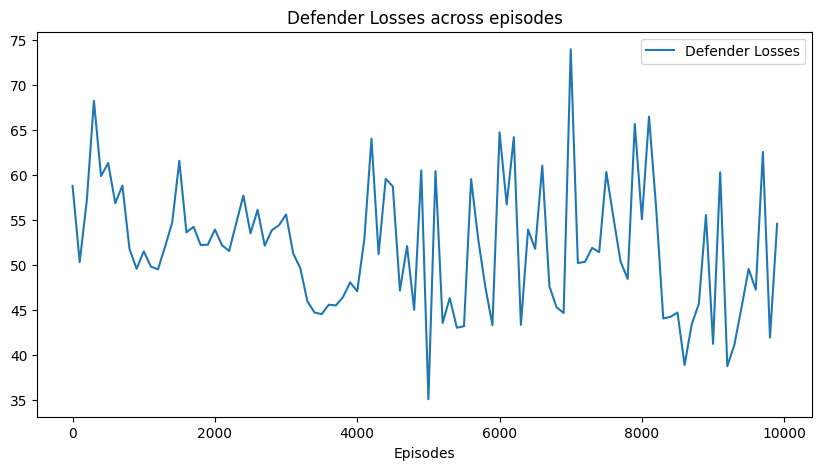

In [36]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),defender_losses, label='Defender Losses')
plt.legend()
plt.title("Defender Losses across episodes")
plt.xlabel("Episodes")

Text(0.5, 0, 'Episodes')

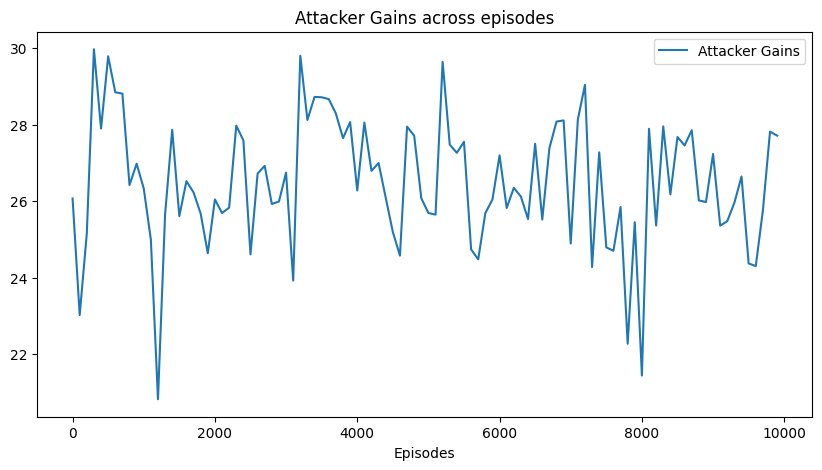

In [37]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),attacker_gains, label='Attacker Gains')
plt.legend()
plt.title("Attacker Gains across episodes")
plt.xlabel("Episodes")

(100, 5)


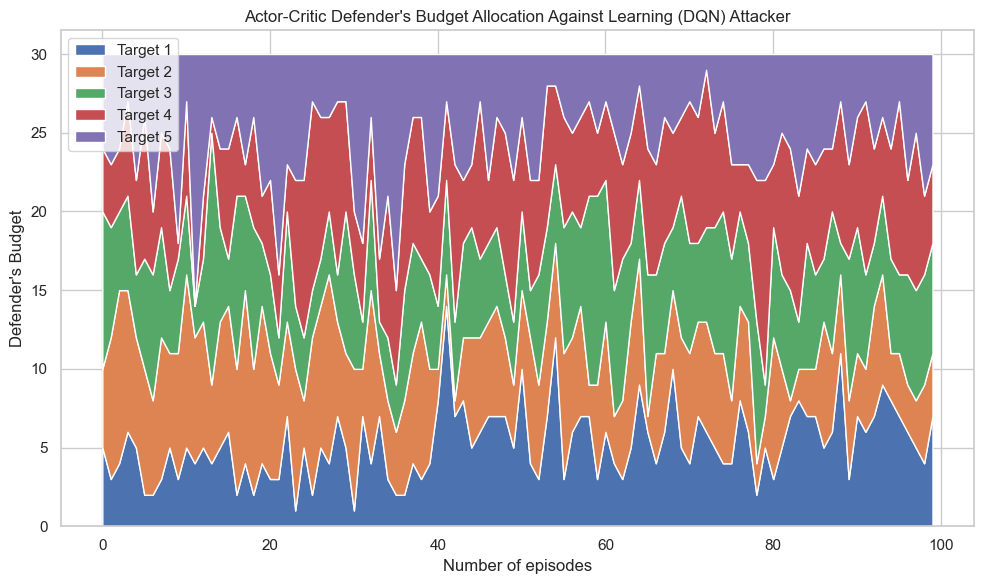

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose defender_allocations is a list of 1000 arrays, each len 5
# Convert it to a NumPy array
data = np.array(defender_allocations)  # shape = (1000, 5)

# Check shape
print(data.shape)  # should print (1000, 5)

# Create x-axis
x = np.arange(len(data))  # shape = (1000,)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Transpose so that each column (5 total) becomes one layer
# Plot stacked area chart
plt.stackplot(x, data.T, labels=[f'Target {i+1}' for i in range(data.shape[1])])

# Add legend and labels
plt.legend(loc='upper left')
plt.title("Actor-Critic Defender's Budget Allocation Against Learning (DQN) Attacker")
plt.xlabel("Number of episodes")
plt.ylabel("Defender's Budget")
plt.tight_layout()
plt.show()
